# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

- General linear models and latent variable models allow us to model nonlinear relationships between probabilities and features. In a logistic regression, an activcation function can convert a linear combination of variables into a probability between 0 and 1. This is good for classification tasks. Linear regression can produce predictions outside this range which makes it not suitable for predicting probabilities.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

- Binary and categorical cross entropy measures the difference between predicted probabilities and true class labels. Loss functions essentially penalize completely confident incorrect predictions. I think this can encourage the model to produce a probability that matches the actual observed data. They also align pretty well with the maximum likelihood estimation for probability models like logistic regressions.

3. True or false, and explain: Logistic regression is a linear model.

- True, logistic regression is consider a linear model in the parameters because it models the log-odds as a linear function of the features and the transformation to probability is nonlinear.

4. True or false, and explain: Logistic regression cannot be used for classification.

- False, logistic regression is used for classification problems and it predicts the probabilities of class membership which can be converted into class labels using a threshold.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

-No, in a logistic regression, coefficients represent the change in log-odds, not the change in predicted probability. The effect on probability depends on the current predicted probability and is not really constant across observations.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

- False, logistic regression is still linear in the features which means a nonlinear relationship must still be created using feature engineering.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

-False, logistic regression is better for classification problems with binary outcomes, but the OLS is better when predicting continuous variables. It is worth nothing that each model is suited for different tasks.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

**I creased a binary outcome variable where dropout = 1 and non-dropout = 0. Missing values were removed since logistic regressions can't handle them.**

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

**Because debtor has a positive coefficient, debt increases dropout probability. Tutition up to date has a negative coefficient which means that paying tutition reduces dropout risk. Scholoarship holder has a negative coefficient which means that scholarships reduce dropout risk. And age has a positive coefficient which means the older students are more likely to dropout. So the strongest predictor seems to be tuition payment status**

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

**It seems that students who are up to date on their tutition payments have lower drouput probabilities across ages. The difference is largest for older students, who have higher dropout risks. Students with tuition paid about a 60 percentage point lower dropout probability.**


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

**The model can correctly classify most students with a 76% accuracy. The model does a decent job at predicting dropout.**

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

**Logistic regression performs better because its predictions are between 0 and 1, while the linear model can produce invalid probabilities like below 0 and above 1. So the logistic regression is the better model for predicting droupout probability.**

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

**Students are more likely to dropout if they are debtors, not up to date on tuition payments, don't have scholarships, or are older. But financial stress seems to be the biggest motivator for dropping out.**

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**The model predicts graduate and dropout at a solid rate, but doesn't do so well with enrolled students. The hard predictions don't include every class because the model chooses the most likely category. But, the predicted probabilities include values for all classes, which means that every class is represented in the probability output. This overall, seems to point to the fact that the enrolled category is harder to distinguish from the others.**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("data.csv", sep=';')
df2 = df[['Debtor',
          'Tuition fees up to date',
          'Scholarship holder',
          'Age at enrollment',
          'Target']].dropna()

df2['Dropout'] = (df2['Target'] == 'Dropout').astype(int)

X = df2[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment']]

y = df2['Dropout']

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X,y)

for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

print("Intercept:", model.intercept_[0])

Debtor 0.5306254196925666
Tuition fees up to date -2.55654243281313
Scholarship holder -1.227441522252298
Age at enrollment 0.04992541246433546
Intercept: 0.4856926578796168


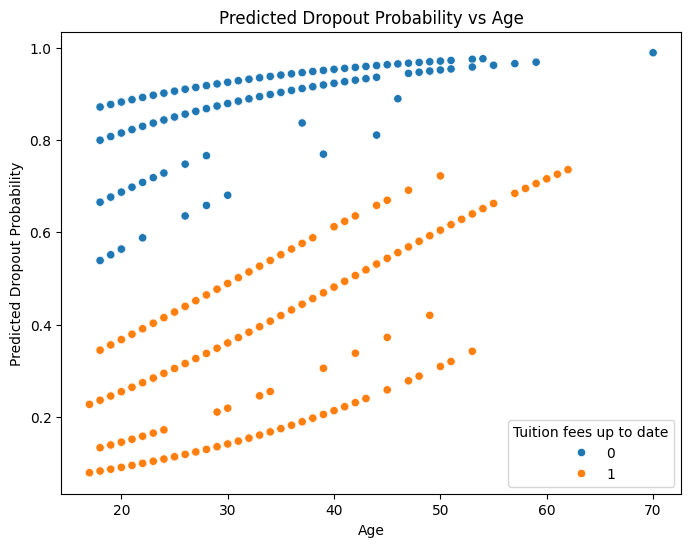

,pred_dropout
Tuition fees up to date,
0,0.860675
1,0.248090


In [15]:
df2['pred_dropout'] = model.predict_proba(X)[:,1]
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df2,
    x="Age at enrollment",
    y="pred_dropout",
    hue="Tuition fees up to date"
)

plt.title("Predicted Dropout Probability vs Age")
plt.xlabel("Age")
plt.ylabel("Predicted Dropout Probability")

plt.show()

df2.groupby('Tuition fees up to date')['pred_dropout'].mean()

In [16]:
y_pred = model.predict(X)

cm = confusion_matrix(y,y_pred)

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y,y_pred)

print("Accuracy:", accuracy)

Confusion Matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


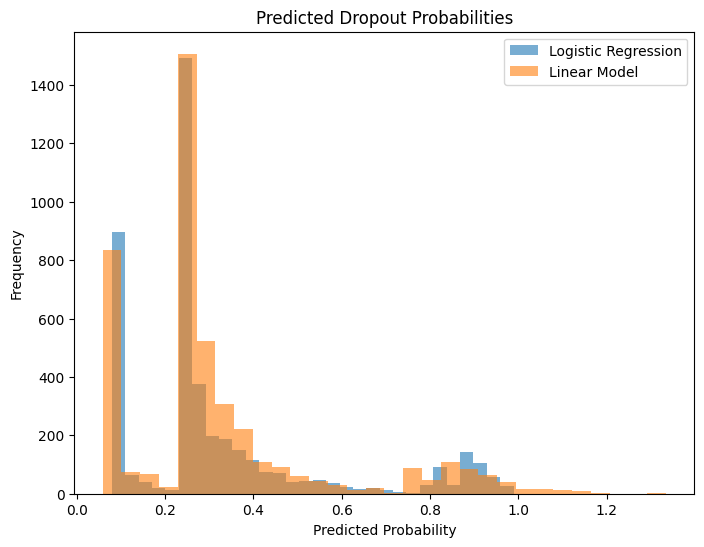

In [17]:
lin_model = LinearRegression()
lin_model.fit(X,y)
log_probs = model.predict_proba(X)[:,1]
lin_probs = lin_model.predict(X)
plt.figure(figsize=(8,6))
plt.hist(log_probs, bins=30, alpha=0.6, label="Logistic Regression")
plt.hist(lin_probs, bins=30, alpha=0.6, label="Linear Model")
plt.legend()
plt.title("Predicted Dropout Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

In [18]:
df2.sort_values("pred_dropout", ascending=False)[
    ['Debtor','Tuition fees up to date',
     'Scholarship holder','Age at enrollment','pred_dropout']
].head(10)

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,pred_dropout
689,1,0,0,70,0.989133
2876,1,0,0,54,0.976161
717,1,0,0,53,0.974971
1887,1,0,0,51,0.972415
3472,1,0,0,50,0.971044
678,1,0,0,50,0.971044
709,1,0,0,50,0.971044
3526,1,0,0,49,0.969607
3281,0,0,0,59,0.968668
4260,1,0,0,48,0.968100


In [19]:
multi_df = df[['Debtor',
               'Tuition fees up to date',
               'Curricular units 1st sem (approved)',
               'Target']].dropna()

X_multi = multi_df[['Debtor',
                    'Tuition fees up to date',
                    'Curricular units 1st sem (approved)']]

y_multi = multi_df['Target']

multi_model = LogisticRegression(max_iter=1000)

multi_model.fit(X_multi,y_multi)
multi_pred = multi_model.predict(X_multi)

cm_multi = confusion_matrix(y_multi, multi_pred)

print("Confusion Matrix:")
print(cm_multi)
multi_probs = multi_model.predict_proba(X_multi)

print(multi_probs[:10])

Confusion Matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]
 [0.30842087 0.32343275 0.36814638]
 [0.07193813 0.14064437 0.78741751]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.8388865  0.12297708 0.03813642]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

**Missing values were handled by dropping any rows that contain NA values because logistic regression can't handle missing data points.**

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

**No, the druge does not improve survival probability because the coefficient for placebo is positive which means the placebo patients had higher survival probability than those receiving the D-pencillamine.**

**Higher bilirubin predicts lower survival probability because its coefficient is negative**

**Survival decreases as edema worsens, Edema S lowers survival than none and Edema Y has much lower survival. So, edema predicts lower survival.**

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

**The drug appears to slightly increase survival probability due to lower bilirubin levels. At higher bilirubin values, the predict survival rate becomes low for both groups and the difference between placebo and drug are minimal. The drug increase survival rpobability by a very small amount, so not really effective**

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

**The accuracy is 0.73, so the model classifies survival outcomes correctly about 73% of the time**

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

**Logistic regression performs better because its predicted probabilities are between 0 and 1. The linear model can produce probabilities below 0 and above 1, which aren't valid. So logistic regression is more appropriate for predicting survival outcomes.**


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**The confusion matrix shows the model has limited accuracy when prediciting the correct disease stage. It's multi-class outcomes and harder to classify overall. The hard classification does not always predict every stage becaise it only assigns the most likely class in this instance. But the predicted probabilities gives probabilities for every stage which means that all classes are represented in the probability output even if they aren't chosen as the final class.**

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cirrhosis.csv")
df = df[['Bilirubin','Edema','Drug','Status']]
df = df.dropna()
df['Survive'] = df['Status'].isin(['C','CL']).astype(int)
X = pd.get_dummies(df[['Bilirubin','Edema','Drug']], drop_first=True)

y = df['Survive']

In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X,y)

for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

print("Intercept:", model.intercept_[0])

Bilirubin -0.35142389843544086
Edema_S -0.45067663255235757
Edema_Y -1.6110491833168035
Drug_Placebo 0.23122512449170882
Intercept: 1.3798277993022918


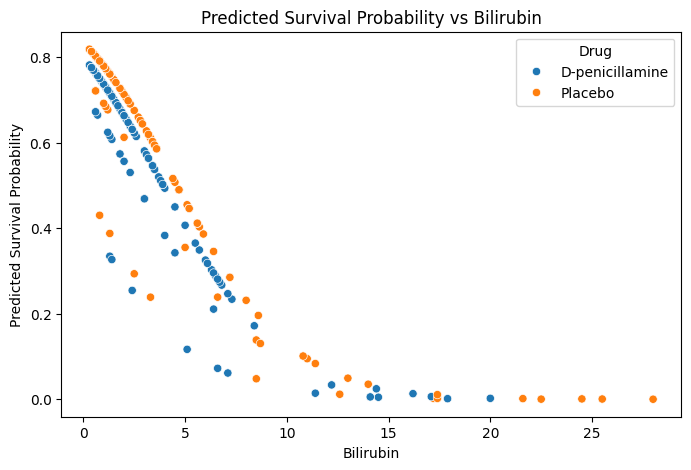

In [8]:
df['predicted_survival'] = model.predict_proba(X)[:,1]

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Bilirubin',
    y='predicted_survival',
    hue='Drug'
)

plt.title("Predicted Survival Probability vs Bilirubin")
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")

plt.show()

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


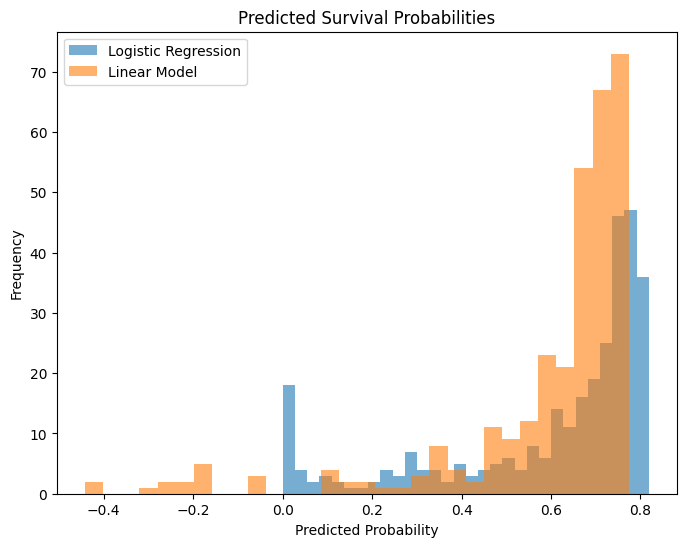

In [10]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X, y)
log_probs = model.predict_proba(X)[:,1]
lin_probs = lin_model.predict(X)
plt.figure(figsize=(8,6))
plt.hist(log_probs, bins=30, alpha=0.6, label="Logistic Regression")
plt.hist(lin_probs, bins=30, alpha=0.6, label="Linear Model")
plt.legend()
plt.title("Predicted Survival Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")

plt.show()

In [11]:
stage_df = pd.read_csv("cirrhosis.csv")[['Stage','Edema','Bilirubin']].dropna()
X_stage = pd.get_dummies(stage_df[['Edema','Bilirubin']], drop_first=True)
y_stage = stage_df['Stage']

stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)
stage_pred = stage_model.predict(X_stage)

from sklearn.metrics import confusion_matrix
cm_stage = confusion_matrix(y_stage, stage_pred)

print("Confusion Matrix:")
print(cm_stage)

Confusion Matrix:
[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]


In [12]:
stage_probs = stage_model.predict_proba(X_stage)

print(stage_probs[:10])

[[4.69310173e-04 5.11101017e-02 1.37332318e-01 8.11088270e-01]
 [6.86748223e-02 2.55045503e-01 3.97580467e-01 2.78699208e-01]
 [3.98444586e-02 1.39559526e-01 3.40088018e-01 4.80507998e-01]
 [3.52173905e-02 1.37517821e-01 3.38842527e-01 4.88422261e-01]
 [3.50488839e-02 2.43194238e-01 4.04018626e-01 3.17738252e-01]
 [7.47981259e-02 2.56037249e-01 3.95826812e-01 2.73337814e-01]
 [7.06630926e-02 2.55393713e-01 3.97023123e-01 2.76920071e-01]
 [8.61123758e-02 2.57315050e-01 3.92336207e-01 2.64236367e-01]
 [3.71989542e-02 2.44458246e-01 4.03877125e-01 3.14465675e-01]
 [8.91762897e-04 5.79492031e-02 1.47733784e-01 7.93425250e-01]]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

**A 1 unit increase in xk changes tthe prediction by bk**

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

**The effect depends on current probability, with the largest at p=0.5 and quite small when p is near 0 or 1. So the coefficients affect the probability most strongly in the middle range**

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

**A 1 unit increase in xk changes the log odds by bk. Exponentiating gives the odds ratio e to the power of bk which essentially represents the multiplicative change in odds.**